# Probability Notes - Chapter 01

**The Relationship Between PMF, PDF and CDF**


In [ ]:
# Beginner-friendly guide:
# We load tools for number lists, probability calculations, and drawing charts.
# The fixed random seed makes any pretend experiment repeat the same way each time.
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11})
rng = np.random.default_rng(42)


# 01 - The Relationship Between PMF, PDF and CDF

**Source alignment:** `2-finalpdf,pmf,cdf (1).pdf`, pages 1-2. The source shows a fair-die PMF and step-shaped CDF, then a continuous density and smooth CDF whose slope gives the density.

## Learning goals

- Tell a discrete random variable from a continuous one.
- Know when to use a PMF, PDF, or CDF.
- Move from a PMF/PDF to a CDF and back.
- Calculate point and interval probabilities correctly.


## 1. Start with a random variable

A **random variable** converts an uncertain outcome into a number.

- Die roll: $X\in\{1,2,3,4,5,6\}$ - discrete.
- Waiting time: $X\in[0,\infty)$ - continuous.
- A discrete variable has separate, countable values.
- A continuous variable can take any real value in an interval.

The **support** is the set of values that are possible.

## 2. The three functions

| Function | Used for | Meaning | Probability rule |
|---|---|---|---|
| PMF $p_X(x)$ | Discrete $X$ | Probability at the exact value $x$ | $P(X=x)=p_X(x)$ |
| PDF $f_X(x)$ | Continuous $X$ | Density near $x$ | $P(a\le X\le b)=\int_a^b f_X(x)\,dx$ |
| CDF $F_X(x)$ | Any $X$ | Probability accumulated up to $x$ | $F_X(x)=P(X\le x)$ |

> PMF values are probabilities. PDF heights are densities. A density may be greater than 1; only its **area** must obey probability rules.


## 3. PMF rules

For a discrete variable:

$$p_X(x)\ge 0,\qquad \sum_x p_X(x)=1$$

For a fair die:

$$p_X(k)=\frac16,\quad k=1,2,3,4,5,6$$

Therefore:

$$P(X\le2)=P(X=1)+P(X=2)=\frac16+\frac16=\frac13$$

## 4. PDF rules

For a continuous variable:

$$f_X(x)\ge 0,\qquad \int_{-\infty}^{\infty} f_X(x)\,dx=1$$

The probability at one exact point is zero:

$$P(X=x)=0$$

This does **not** mean the value is impossible. It means a single point has zero width and therefore zero area.


## 5. CDF rules - valid for every distribution

$$F_X(x)=P(X\le x)$$

Every CDF:

- stays between 0 and 1;
- never decreases;
- approaches 0 as $x\to-\infty$;
- approaches 1 as $x\to\infty$;
- is right-continuous.

Interval probabilities come from subtraction:

$$P(a<X\le b)=F_X(b)-F_X(a)$$

Endpoint details matter for discrete variables. For continuous variables, $<$ and $\le$ give the same probability because point probabilities are zero.

## 6. How the functions connect

**Discrete:**

$$F_X(x)=\sum_{k\le x}p_X(k)$$

If the support contains consecutive integers:

$$p_X(k)=F_X(k)-F_X(k-1)$$

**Continuous:**

$$F_X(x)=\int_{-\infty}^{x}f_X(t)\,dt$$

Wherever the derivative exists:

$$f_X(x)=\frac{d}{dx}F_X(x)$$

This matches the source diagram: the CDF's **slope** is the PDF's height.


In [ ]:
# Beginner-friendly guide:
# We make the six die faces, give every face the same chance, then keep a running total for the CDF.
# The left picture shows separate chances; the right picture shows chance collected so far.
# Discrete example: fair-die PMF and CDF
x = np.arange(1, 7)
pmf = np.repeat(1/6, 6)
cdf = np.cumsum(pmf)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].stem(x, pmf, basefmt=" ")
ax[0].set(title="Fair die: PMF", xlabel="x", ylabel="P(X=x)", ylim=(0, 1))
ax[1].step(np.r_[0, x, 7], np.r_[0, 0, cdf], where="post")
ax[1].set(title="Fair die: CDF", xlabel="x", ylabel="P(X<=x)", ylim=(-.03, 1.05))
plt.tight_layout()

print("P(X <= 2) =", pmf[:2].sum())
print("CDF at 2   =", cdf[1])


In [ ]:
# Beginner-friendly guide:
# We make a smooth bell curve and ask SciPy for its height (PDF) and running total (CDF).
# The shaded part is the chance of landing between -1 and 1, so it is found from area.
# Continuous example: standard-normal PDF and CDF
x = np.linspace(-4, 4, 500)
pdf = stats.norm.pdf(x)
cdf = stats.norm.cdf(x)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, pdf)
ax[0].fill_between(x, 0, pdf, where=(x >= -1) & (x <= 1), alpha=.3)
ax[0].set(title="PDF: probability is area", xlabel="x", ylabel="density")
ax[1].plot(x, cdf)
ax[1].set(title="CDF: accumulated probability", xlabel="x", ylabel="F(x)", ylim=(-.03, 1.03))
plt.tight_layout()

p_between = stats.norm.cdf(1) - stats.norm.cdf(-1)
print(f"P(-1 <= X <= 1) = {p_between:.4f}")


## Advanced connection: mixed distributions

Some variables have both point masses and continuous regions. Example: an insurance payment may be exactly $0$ with positive probability, but positive payments vary continuously.

- The CDF still works without modification.
- A jump in the CDF equals a point probability.
- A smooth region's slope gives density.

## Common mistakes

- Saying “PDF = probability at $x$.” It is density, not point probability.
- Calling CDF “cumulative density function.” The correct term is **cumulative distribution function**.
- Adding PDF heights instead of calculating area.
- Forgetting that a discrete CDF is step-shaped.

## Quick recall

- **PMF:** exact probability for discrete values.
- **PDF:** area gives probability for continuous values.
- **CDF:** probability up to a value; works for both.
- **CDF from PMF/PDF:** cumulative sum or integral.
- **PMF/PDF from CDF:** jump difference or derivative.


## Chapter mini-cheatsheet

Re-read the **core idea**, **main formulas**, **worked example**, and **common mistakes** above. Then explain the topic aloud without looking.


## Friendly theory: PMF, PDF and CDF are three ways to tell a chance story

> **You already have the detailed notes above. This extra section explains the same ideas in very simple words.**

Imagine that probability is a tiny helper who answers, “How likely is that?” The helper can use three different picture books:

| Helper | Imagine it as | What it tells us |
| --- | --- | --- |
| **PMF** | Separate toy boxes | The chance of each countable answer, such as 1, 2, 3, 4, 5, or 6 on a die. |
| **PDF** | A smooth hill on a ruler | Where continuous answers are crowded. A taller part means answers near there are more common. |
| **CDF** | A piggy bank that only fills up | The total chance collected from the far left up to a chosen number. |

### Tiny story

For a fair die, the PMF says each face has chance `1/6`. The CDF answers questions such as “What is the chance of getting **at most 3**?” It collects faces 1, 2, and 3, so the answer is `3/6`.

For a continuous measurement, such as a child's height, a PDF is different: the chance of **exactly one perfect height** is effectively zero. We find chance by looking at an **area over a small stretch**, for example “between 100 cm and 105 cm.”

### One easy rule

- Ask “**exactly this count?**” → use a **PMF** for countable values.
- Ask “**up to this value?**” → use the **CDF**.
- Ask “**between these two values?**” → subtract: `CDF at the right - CDF at the left`.
- See a smooth hill? Remember: its **area**, not its height at one dot, is probability.

### Remember it

**PMF = separate dots. PDF = smooth hill. CDF = running total.**


## Supplied visual notes: PMF, PDF, and CDF

The next three pages are the supplied handwritten lecture notes. Read the friendly theory section immediately after them for the full, standard terminology and formulas.

### Page 1: distribution functions, a fair-die PMF, and the die CDF

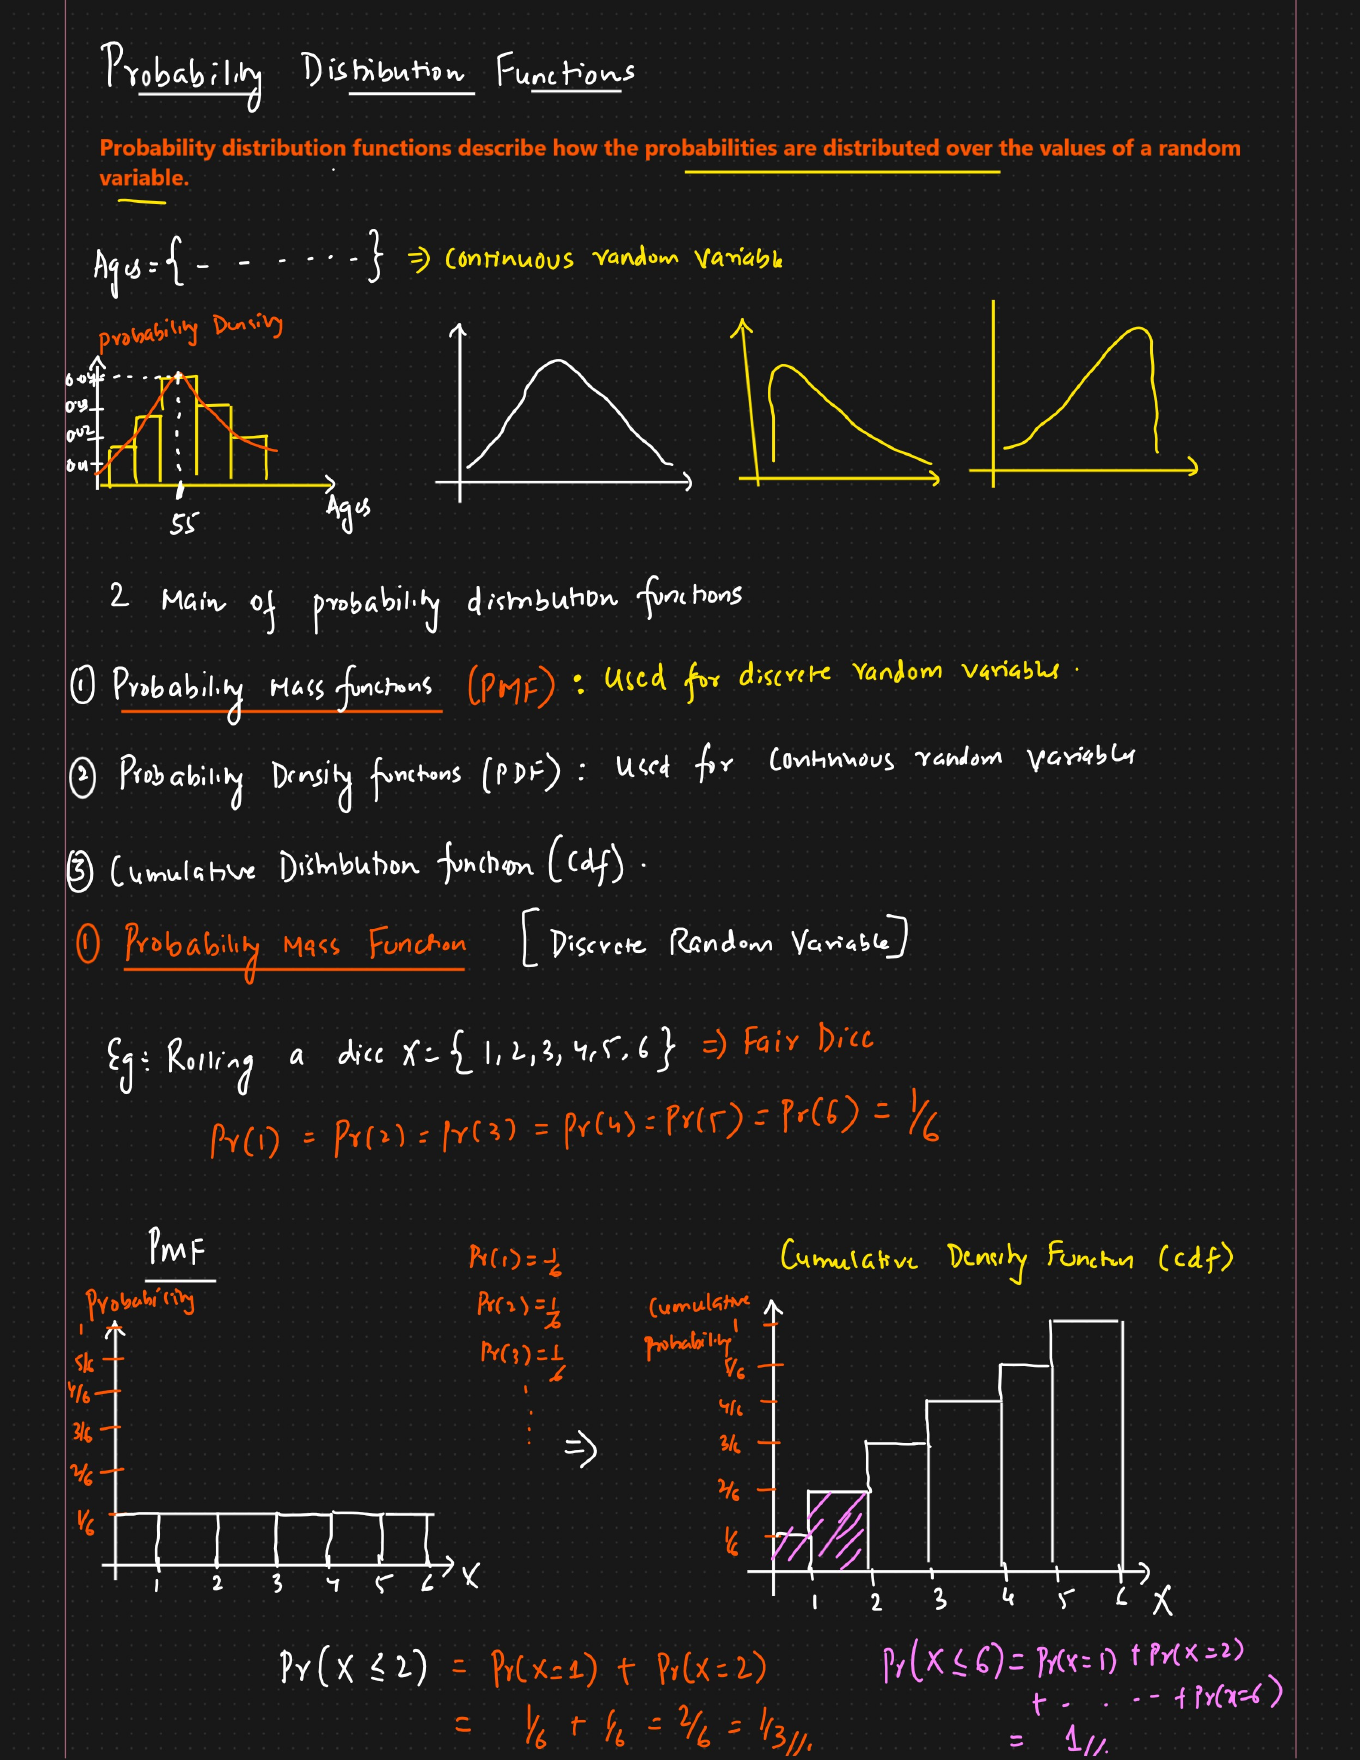

### Page 2: continuous PDF, CDF, area, and slope

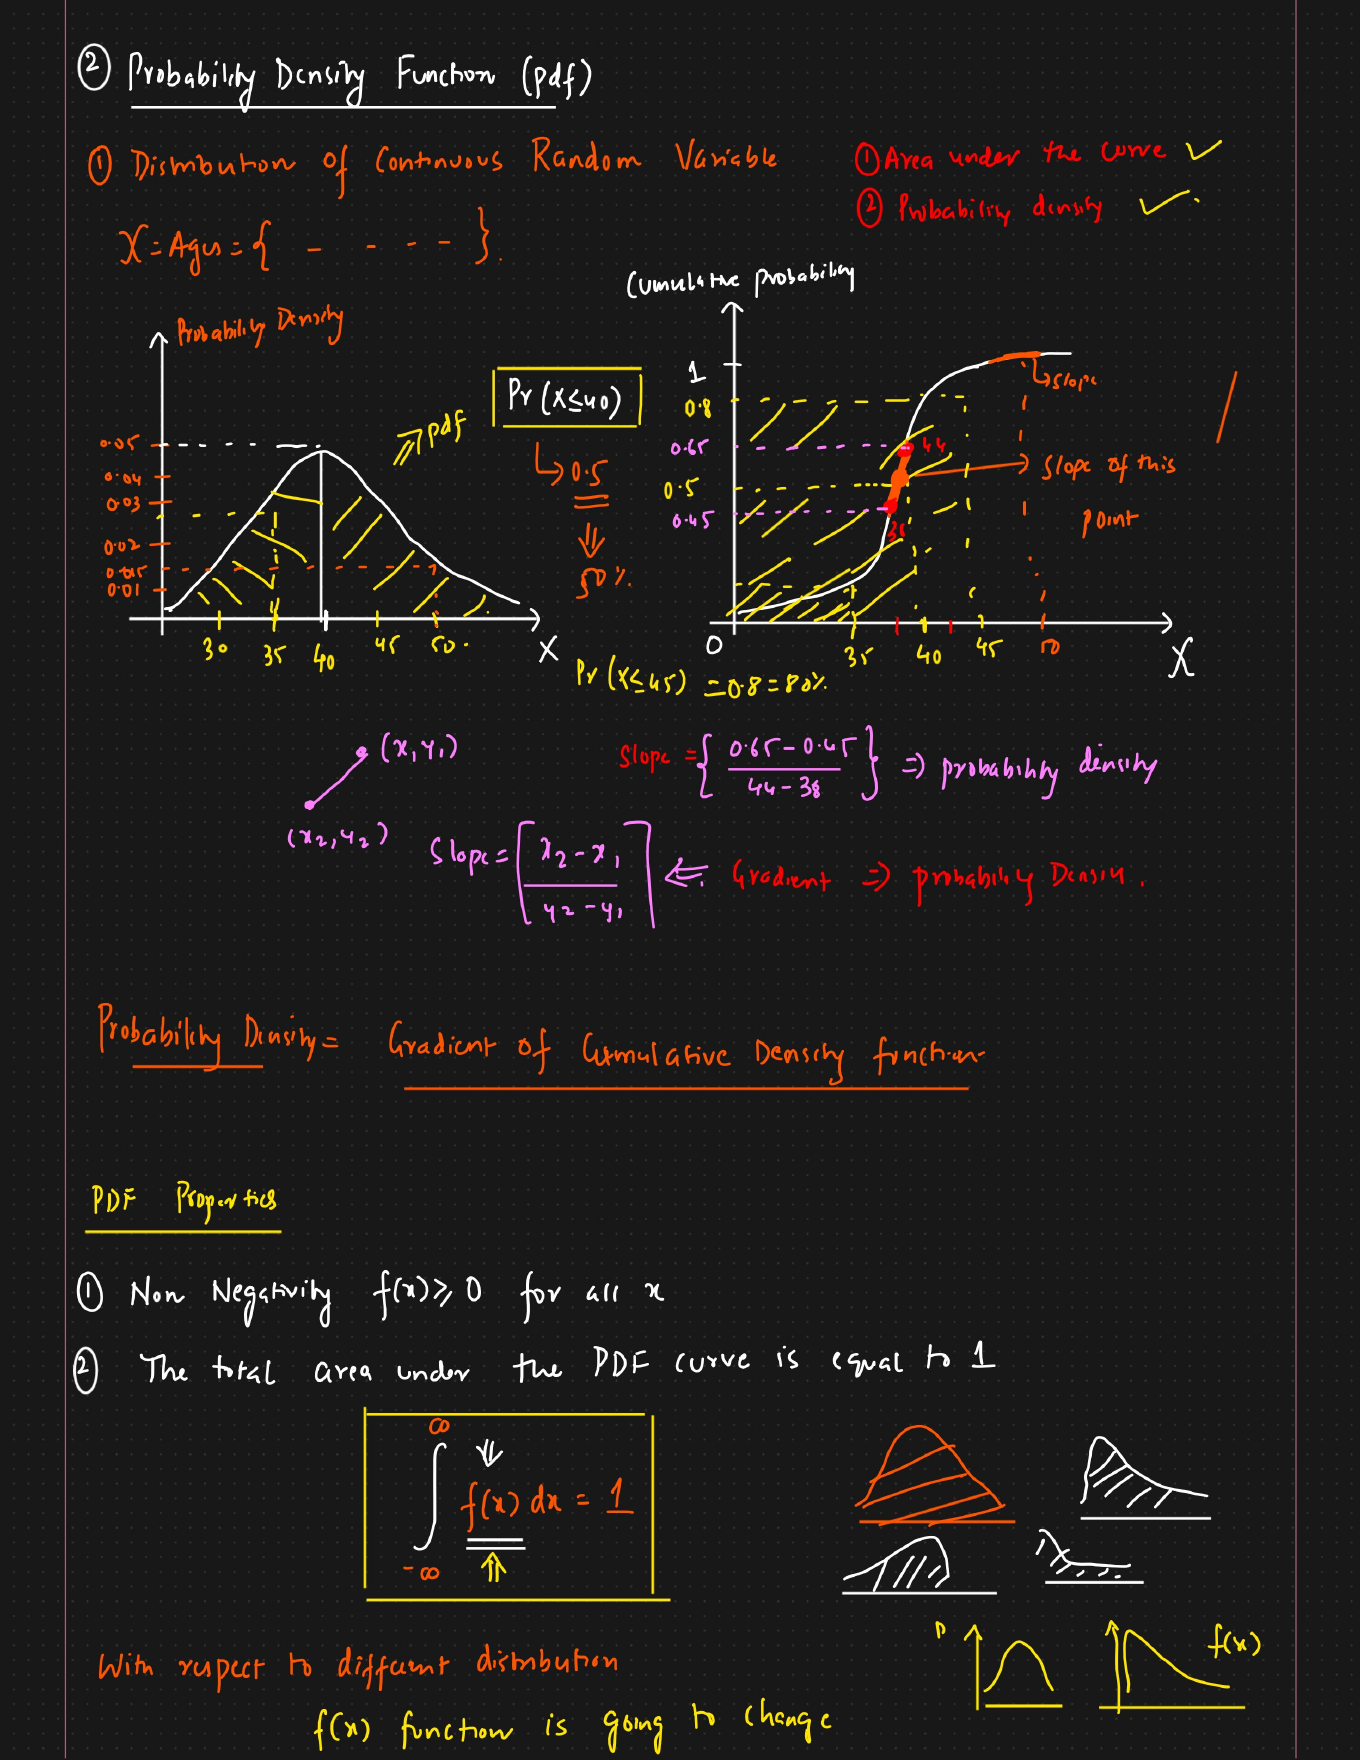

### Page 3: choosing PMF or PDF for different variables

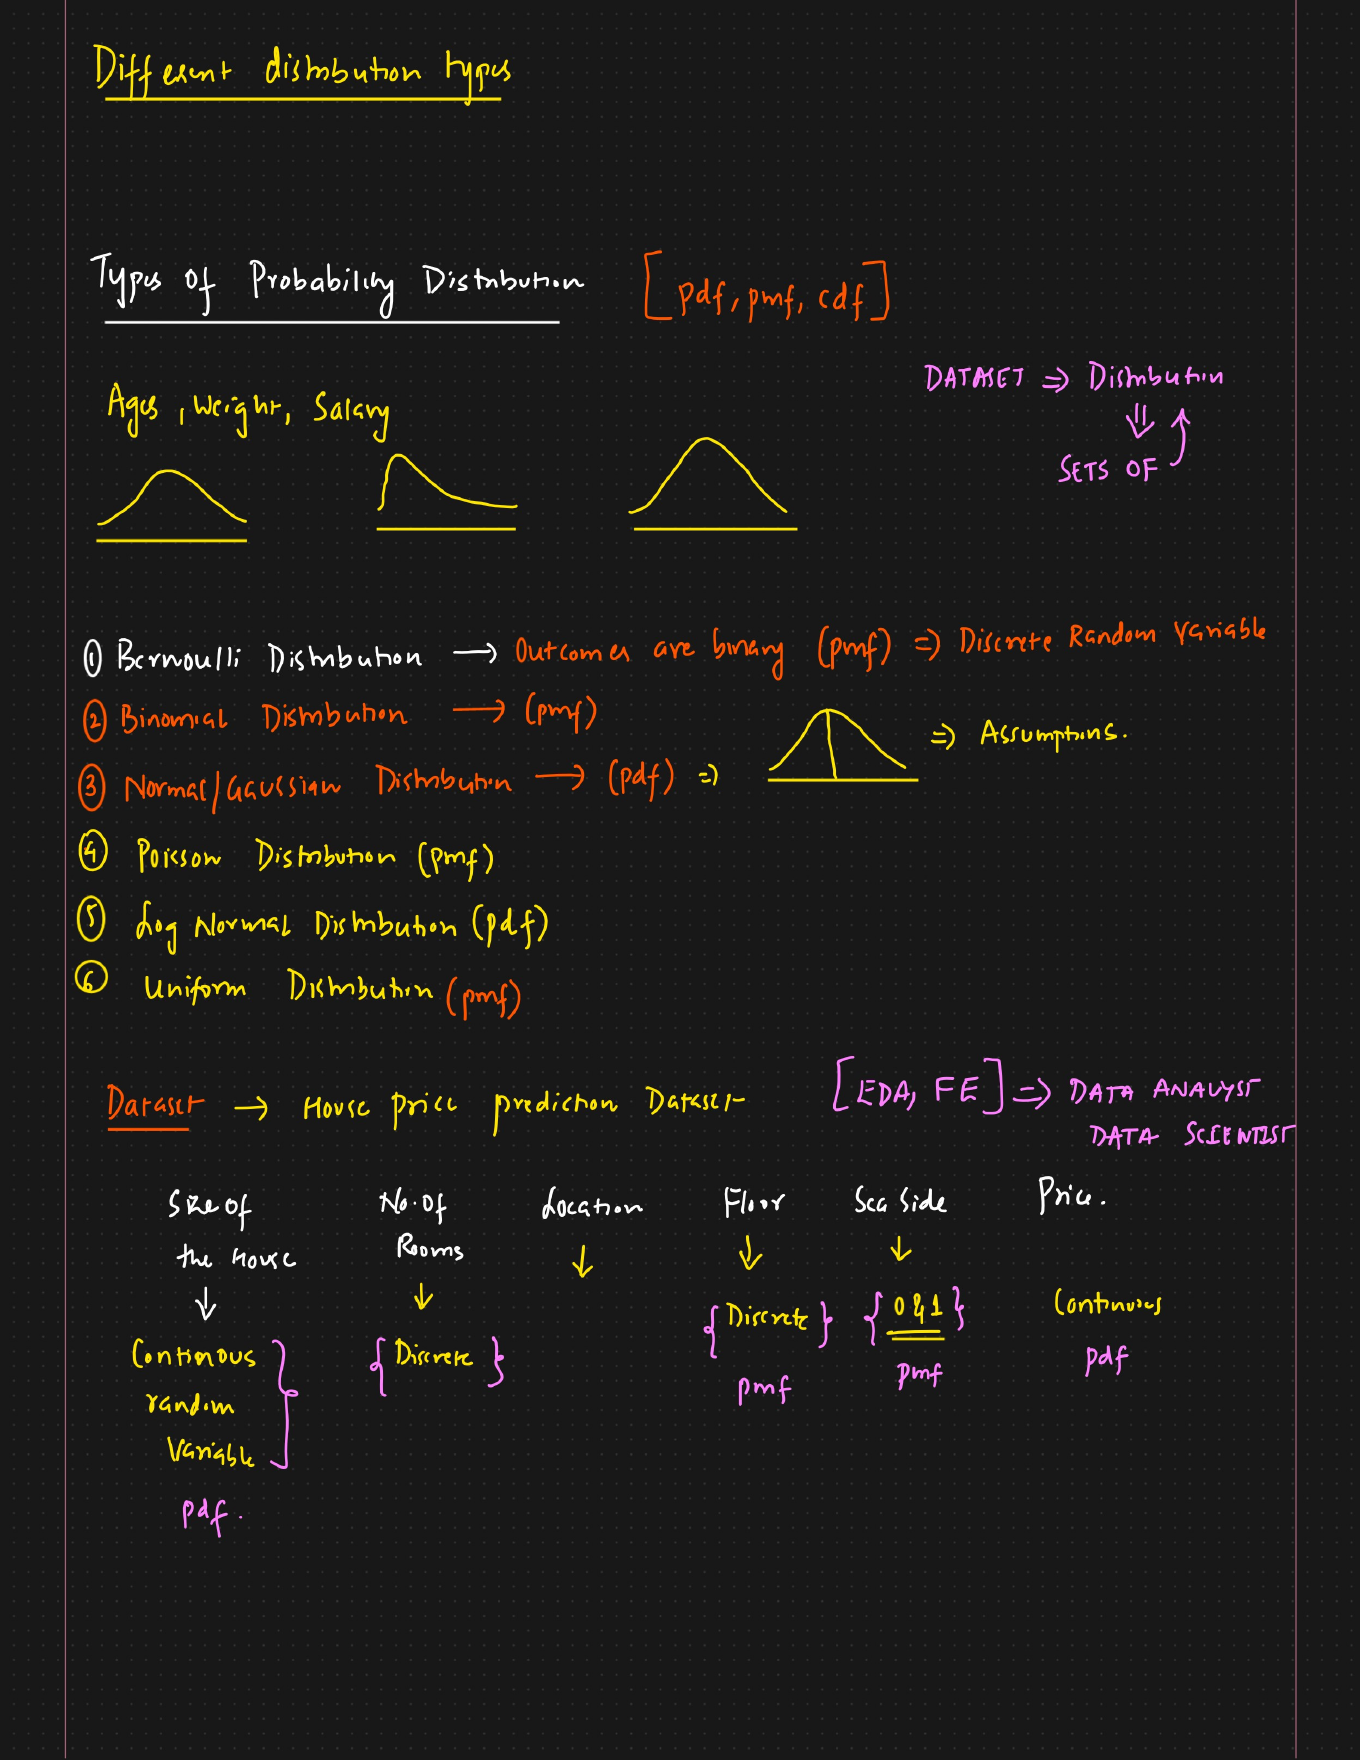


## PDF companion: understand PMF, PDF, and CDF from the pictures

> **Simple picture:** Imagine probability as a story about where an answer can land. A PMF uses separate boxes, a PDF uses a smooth hill, and a CDF is a bucket that keeps collecting probability from the left.

### 1. Start by asking: can we count the answers or measure them?

| Random-variable type | Easy examples | Best first function |
| --- | --- | --- |
| **Discrete**: separate, countable answers | die face, number of rooms, number of children | **PMF** |
| **Continuous**: any value along a scale | age, height, weight, house size, price | **PDF** |

The **CDF** works for both types. It always answers “what is the chance that the value is at most this point?”

### 2. PMF: probability for separate answers

For a discrete random variable $X$, the probability mass function is:

$$
p(x)=P(X=x)
$$

For a fair die, $X$ can be 1, 2, 3, 4, 5, or 6. Every face has the same chance:

$$
P(X=1)=P(X=2)=\cdots=P(X=6)=\frac{1}{6}
$$

The bars in a PMF are separate because a die cannot land on 2.4. PMF rules are simple:

$$
p(x)\ge0
\qquad\text{and}\qquad
\sum_x p(x)=1
$$

### 3. CDF: probability collected so far

The cumulative distribution function is:

$$
F(x)=P(X\le x)
$$

For the fair die, the picture is a staircase. At $x=2$, we collect the chance of face 1 and face 2:

$$
F(2)=P(X\le2)=P(X=1)+P(X=2)=\frac16+\frac16=\frac13
$$

At the far right, the whole staircase reaches 1 because all possible probability has been collected. For any two points $a<b$:

$$
P(a<X\le b)=F(b)-F(a)
$$

### 4. PDF: density for a smooth measurement

For a continuous variable, such as age, there are infinitely many possible values between 35 and 40. So the height of a smooth curve is **density**, not the probability of one exact point.

$$
f(x)\ge0
\qquad\text{and}\qquad
\int_{-\infty}^{\infty}f(x)\,dx=1
$$

The probability of an interval is the area under the curve:

$$
P(a\le X\le b)=\int_a^b f(x)\,dx
$$

That is why the shaded area in the PDF picture matters. For a continuous variable, $P(X=40)=0$; an exact single point has no width. A range such as “between 35 and 40” has width, so it can have probability.

### 5. The powerful PDF-CDF connection

The CDF is the area accumulated under the PDF from the far left up to $x$:

$$
F(x)=\int_{-\infty}^{x}f(t)\,dt
$$

The PDF is the slope, or gradient, of the CDF:

$$
f(x)=F'(x)
$$

So a steep part of the CDF means probability is piling up quickly there, which means the PDF is high. A flat part of the CDF means little or no density in that region.

### 6. One vocabulary correction from the visual notes

The standard name of **CDF** is **cumulative distribution function**, not “cumulative density function.” Its meaning is still the same: it is the running total of probability up to a chosen value.

### Tiny final memory trick

- **PMF:** separate answers, exact probability, bars or dots.
- **PDF:** continuous measurements, probability is area, smooth curve.
- **CDF:** chance up to a value, always rises from 0 toward 1.

When you see a probability question, first decide whether the random variable is countable or continuous. That one choice tells you whether PMF or PDF is the right starting picture.
